# Step 4. Long-Short 전략

BL 롱온리의 한계(Sharpe < 벤치마크)를 극복하기 위해 롱숏 전략 구현.

| 전략 | 방식 | 기대 효과 |
|------|------|-----------|
| **Strategy 1** | 퀀타일 L/S | Q 상위 20% 매수 + 하위 20% 공매도, 동일가중 |
| **Strategy 2** | BL L/S | BL posterior + 숏 허용 MVO, 달러 뉴트럴 |

**핵심 메커니즘**: 롱숏은 시장 베타를 제거해 분모(변동성)를 줄임 → 같은 IC로 더 높은 Sharpe

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

for _fp in fm.findSystemFonts(fontext='ttf'):
    if 'malgun' in _fp.lower() or 'nanum' in _fp.lower():
        plt.rcParams['font.family'] = fm.FontProperties(fname=_fp).get_name()
        break
plt.rcParams['axes.unicode_minus'] = False

TOP_N           = 100
MIN_HIST_MONTHS = 36
DELTA           = 2.5
TAU             = 0.05
QUINTILE        = 0.20      # 상위/하위 몇 %
W_MAX_LONG      = 0.10      # 롱 최대 비중
W_MAX_SHORT     = 0.05      # 숏 최대 비중 (절댓값)
TC              = 10 / 10_000

DATA_DIR   = Path('data')
PRED_DIR   = Path('outputs/step2_xgb')
OUTPUT_DIR = Path('outputs/step4_ls')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('설정 완료')
print(f'  Quintile={QUINTILE:.0%}, W_MAX_LONG={W_MAX_LONG:.0%}, W_MAX_SHORT={W_MAX_SHORT:.0%}')

설정 완료
  Quintile=20%, W_MAX_LONG=10%, W_MAX_SHORT=5%


---
## Section 1. 데이터 로드

In [2]:
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', index_col='date', parse_dates=True)
panel = panel.sort_index()

oos_raw = pd.read_csv(PRED_DIR / 'oos_predictions.csv', index_col='date', parse_dates=True)
oos_raw = oos_raw.sort_index()

def resample_to_monthly(df, value_cols):
    tmp = df.reset_index().copy()
    tmp['month'] = tmp['date'].dt.to_period('M')
    monthly = (
        tmp.sort_values('date')
        .groupby(['month', 'ticker'])
        .last()
        .reset_index()
    )
    return {col: monthly.pivot(index='month', columns='ticker', values=col)
            for col in value_cols}

panel_pivots = resample_to_monthly(
    panel[['ticker', 'fwd_excess_ret_1m', 'log_mcap']],
    value_cols=['fwd_excess_ret_1m', 'log_mcap']
)
ret_pivot  = panel_pivots['fwd_excess_ret_1m']
mcap_pivot = panel_pivots['log_mcap']

oos_pivots  = resample_to_monthly(
    oos_raw[['ticker', 'pred', 'resid']],
    value_cols=['pred', 'resid']
)
pred_pivot  = oos_pivots['pred']
resid_pivot = oos_pivots['resid']

n_pred = pred_pivot.notna().sum(axis=1)
rebal_months = n_pred[n_pred >= TOP_N].index

print(f'리밸런싱 가능 월: {len(rebal_months)}개  ({rebal_months.min()} ~ {rebal_months.max()})')

리밸런싱 가능 월: 215개  (2007-02 ~ 2025-11)


---
## Section 2. 헬퍼 함수

In [3]:
def estimate_cov(ret_df):
    clean = ret_df.ffill().fillna(0)
    return LedoitWolf().fit(clean.values).covariance_


def bl_posterior(Q, Omega, cov, pi, tau):
    inv_tau_cov = np.linalg.inv(tau * cov)
    inv_omega   = np.linalg.inv(Omega)
    M    = np.linalg.inv(inv_tau_cov + inv_omega)
    mu   = M @ (inv_tau_cov @ pi + inv_omega @ Q)
    return mu, cov + M


def mvo_longonly(mu, cov, gamma, w_max=W_MAX_LONG):
    n  = len(mu)
    w0 = np.ones(n) / n
    res = minimize(
        lambda w: -(w @ mu - (gamma/2) * (w @ cov @ w)),
        w0, method='SLSQP',
        bounds=[(0.0, w_max)] * n,
        constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1.0}],
        options={'ftol': 1e-12, 'maxiter': 500}
    )
    return res.x if res.success else w0


def mvo_longhsort(mu, cov, gamma, w_max_long=W_MAX_LONG, w_max_short=W_MAX_SHORT):
    """달러 뉴트럴 MVO: Σw = 0, -w_max_short ≤ w ≤ w_max_long"""
    n  = len(mu)
    w0 = np.zeros(n)
    res = minimize(
        lambda w: -(w @ mu - (gamma/2) * (w @ cov @ w)),
        w0, method='SLSQP',
        bounds=[(-w_max_short, w_max_long)] * n,
        constraints=[{'type': 'eq', 'fun': lambda w: w.sum()}],
        options={'ftol': 1e-12, 'maxiter': 500}
    )
    return res.x if res.success else w0


def portfolio_metrics(rets):
    ann_ret = rets.mean() * 12
    ann_vol = rets.std()  * sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol > 1e-12 else np.nan
    cum     = (1 + rets).cumprod()
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    return {'Ann.Return': ann_ret, 'Ann.Vol': ann_vol, 'Sharpe': sharpe, 'MDD': mdd}


print('헬퍼 함수 정의 완료')

헬퍼 함수 정의 완료


---
## Section 3. Strategy 1: 퀀타일 롱숏

가장 단순한 버전. BL 없이 Q 예측값만으로.

```
매수: 시총 상위 100 중 Q 상위 20% (20종목), 동일가중 +5%씩
공매도: 시총 상위 100 중 Q 하위 20% (20종목), 동일가중 -5%씩
달러 뉴트럴: 순 포지션 = 0
```

In [4]:
q_returns   = []
prev_w_q    = pd.Series(dtype=float)
skipped_q   = 0

for t in rebal_months:
    mcap_t    = mcap_pivot.loc[t].dropna()
    top100    = mcap_t.nlargest(TOP_N).index
    q_t       = pred_pivot.loc[t, top100].dropna()

    if len(q_t) < int(TOP_N * QUINTILE) * 2 + 5:
        skipped_q += 1
        continue

    n_side = int(len(q_t) * QUINTILE)
    long_t  = q_t.nlargest(n_side).index
    short_t = q_t.nsmallest(n_side).index

    w = pd.Series(0.0, index=top100)
    w[long_t]  = +1.0 / n_side
    w[short_t] = -1.0 / n_side

    ret_t = ret_pivot.loc[t, w.index].fillna(0)

    turnover = (w - prev_w_q.reindex(w.index).fillna(0)).abs().sum()
    tc_cost  = turnover * TC

    port_ret = float(w @ ret_t) - tc_cost
    q_returns.append({'month': t, 'ret': port_ret})
    prev_w_q = w

qs_series = pd.DataFrame(q_returns).set_index('month')['ret']
print(f'퀀타일 L/S 완료  (스킵: {skipped_q}, 리밸런싱: {len(qs_series)}회)')
print(f'기간: {qs_series.index.min()} ~ {qs_series.index.max()}')

퀀타일 L/S 완료  (스킵: 0, 리밸런싱: 215회)
기간: 2007-02 ~ 2025-11


---
## Section 4. Strategy 2: BL 롱숏 (달러 뉴트럴 MVO)

In [5]:
GAMMAS_LS = {'중립형': 3.0, '보수형': 8.0}

bl_ls_returns = {g: [] for g in GAMMAS_LS}
prev_w_bl     = {g: {} for g in GAMMAS_LS}
skipped_bl    = 0

for t in rebal_months:
    mcap_t    = mcap_pivot.loc[t].dropna()
    top100    = mcap_t.nlargest(TOP_N).index
    q_raw     = pred_pivot.loc[t, top100].dropna()

    if len(q_raw) < 20:
        skipped_bl += 1
        continue

    universe = q_raw.index.tolist()

    past_months = ret_pivot.index[ret_pivot.index < t]
    hist_months = past_months[-MIN_HIST_MONTHS:]
    if len(hist_months) < MIN_HIST_MONTHS // 2:
        skipped_bl += 1
        continue

    ret_hist = ret_pivot.loc[hist_months, universe]
    valid    = ret_hist.notna().sum() >= len(hist_months) // 2
    universe = ret_hist.columns[valid].tolist()
    if len(universe) < 20:
        skipped_bl += 1
        continue

    cov = estimate_cov(ret_pivot.loc[hist_months, universe])

    cap_vals = np.exp(mcap_t.reindex(universe).fillna(mcap_t.min()).values)
    w_mkt    = cap_vals / cap_vals.sum()
    pi       = DELTA * cov @ w_mkt

    past_resid = resid_pivot.loc[resid_pivot.index < t, universe]
    if len(past_resid) < 3:
        fallback   = resid_pivot.stack().var()
        omega_diag = np.full(len(universe), max(fallback, 1e-6))
    else:
        omega_diag = past_resid.var().fillna(past_resid.stack().var()).values
        omega_diag = np.maximum(omega_diag, 1e-8)
    Omega = np.diag(omega_diag)

    Q_vec = q_raw.reindex(universe).fillna(0).values

    try:
        mu_bl, cov_bl = bl_posterior(Q_vec, Omega, cov, pi, TAU)
    except np.linalg.LinAlgError:
        skipped_bl += 1
        continue

    ret_t = ret_pivot.loc[t, universe].fillna(0).values

    for gname, gamma in GAMMAS_LS.items():
        w_opt = mvo_longhsort(mu_bl, cov_bl, gamma)

        prev_vec = np.array([prev_w_bl[gname].get(tk, 0.0) for tk in universe])
        tc_cost  = np.abs(w_opt - prev_vec).sum() * TC

        port_ret = float(w_opt @ ret_t) - tc_cost
        bl_ls_returns[gname].append({'month': t, 'ret': port_ret})
        prev_w_bl[gname] = dict(zip(universe, w_opt))

bl_ls_series = {
    g: pd.DataFrame(v).set_index('month')['ret']
    for g, v in bl_ls_returns.items()
}

print(f'BL L/S 완료  (스킵: {skipped_bl})')
print(f'리밸런싱: {len(bl_ls_series["중립형"])}회')

BL L/S 완료  (스킵: 0)
리밸런싱: 215회


---
## Section 5. 벤치마크 구성

In [6]:
common_months = qs_series.index

bench_cap_rets, bench_ew_rets = [], []
for t in common_months:
    mcap_t    = mcap_pivot.loc[t].dropna().nlargest(TOP_N)
    universe_b = mcap_t.index
    ret_t_b    = ret_pivot.loc[t, universe_b].fillna(0)

    cap_vals   = np.exp(mcap_t.values)
    w_cap      = cap_vals / cap_vals.sum()
    bench_cap_rets.append({'month': t, 'ret': float(w_cap @ ret_t_b.values)})
    bench_ew_rets.append({'month': t,  'ret': float(ret_t_b.mean())})

bench_cap = pd.DataFrame(bench_cap_rets).set_index('month')['ret']
bench_ew  = pd.DataFrame(bench_ew_rets).set_index('month')['ret']

print('벤치마크 준비 완료')

벤치마크 준비 완료


---
## Section 6. 성과 분석

In [7]:
rows = []

for gname, s in bl_ls_series.items():
    m = portfolio_metrics(s.reindex(common_months).dropna())
    m['Strategy'] = f'BL-L/S {gname}'
    rows.append(m)

m = portfolio_metrics(qs_series)
m['Strategy'] = '퀀타일 L/S'
rows.append(m)

m = portfolio_metrics(bench_cap)
m['Strategy'] = '시총가중 BM'
rows.append(m)

m = portfolio_metrics(bench_ew)
m['Strategy'] = '동일가중 BM'
rows.append(m)

perf_df = pd.DataFrame(rows).set_index('Strategy')[['Ann.Return','Ann.Vol','Sharpe','MDD']]
perf_pct = perf_df.copy()
perf_pct[['Ann.Return','Ann.Vol','MDD']] *= 100

print('=== 롱숏 성과 요약 ===')
print(perf_pct.round(2).to_string())

=== 롱숏 성과 요약 ===
            Ann.Return  Ann.Vol  Sharpe    MDD
Strategy                                      
BL-L/S 중립형       -2.08    14.62   -0.14 -62.64
BL-L/S 보수형       -0.71     6.06   -0.12 -30.65
퀀타일 L/S           0.10    17.87    0.01 -63.13
시총가중 BM           8.63    16.15    0.53 -59.57
동일가중 BM           9.00    16.17    0.56 -52.64


---
## Section 7. 시각화

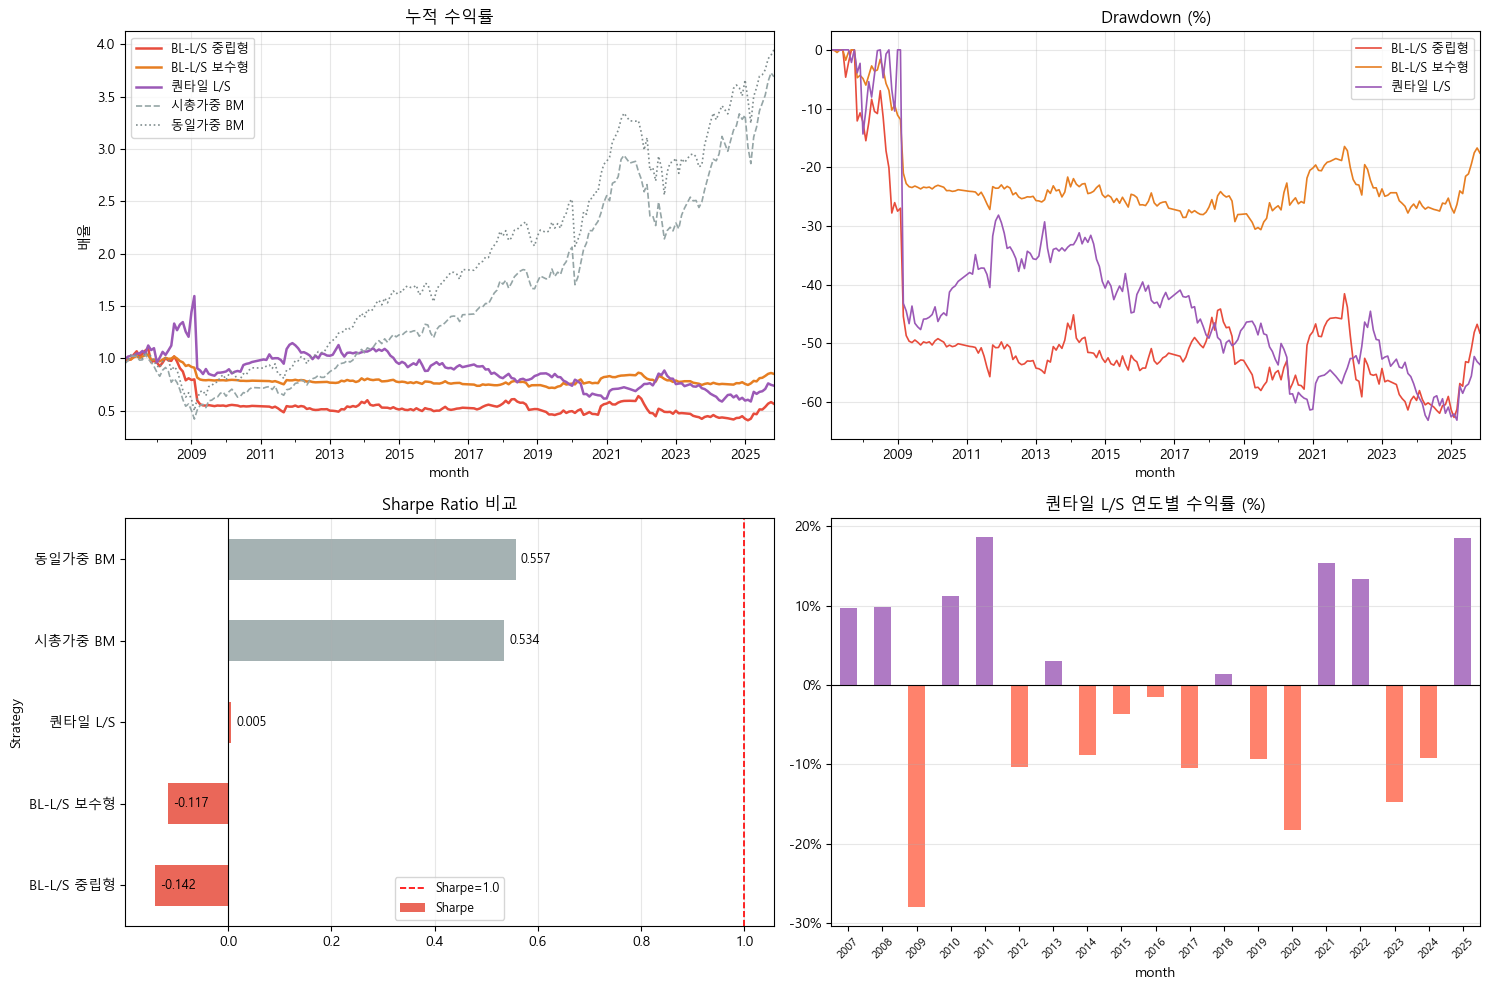

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

COLORS = {
    'BL-L/S 중립형': '#e74c3c',
    'BL-L/S 보수형': '#e67e22',
    '퀀타일 L/S':    '#9b59b6',
}

# ── 누적 수익률 ──────────────────────────────────────────────────────────
ax1 = axes[0, 0]
for gname, s in bl_ls_series.items():
    s_c = s.reindex(common_months).dropna()
    (1 + s_c).cumprod().plot(ax=ax1, label=f'BL-L/S {gname}',
                              color=COLORS[f'BL-L/S {gname}'], lw=1.8)
(1 + qs_series).cumprod().plot(ax=ax1, label='퀀타일 L/S',
                                color=COLORS['퀀타일 L/S'], lw=1.8)
(1 + bench_cap).cumprod().plot(ax=ax1, label='시총가중 BM',
                                color='#95a5a6', lw=1.2, ls='--')
(1 + bench_ew).cumprod().plot(ax=ax1,  label='동일가중 BM',
                               color='#7f8c8d', lw=1.2, ls=':')
ax1.set_title('누적 수익률')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylabel('배율')

# ── Drawdown ─────────────────────────────────────────────────────────────
ax2 = axes[0, 1]
for gname, s in bl_ls_series.items():
    s_c = s.reindex(common_months).dropna()
    cum = (1 + s_c).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    dd.plot(ax=ax2, label=f'BL-L/S {gname}', color=COLORS[f'BL-L/S {gname}'], lw=1.2)
cum_q = (1 + qs_series).cumprod()
dd_q  = (cum_q - cum_q.cummax()) / cum_q.cummax() * 100
dd_q.plot(ax=ax2, label='퀀타일 L/S', color=COLORS['퀀타일 L/S'], lw=1.2)
ax2.set_title('Drawdown (%)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ── Sharpe 막대 ───────────────────────────────────────────────────────────
ax3 = axes[1, 0]
sharpe_vals = perf_pct['Sharpe'].sort_values(ascending=True)
colors_bar  = ['#e74c3c' if 'L/S' in i else '#95a5a6' for i in sharpe_vals.index]
sharpe_vals.plot(kind='barh', ax=ax3, color=colors_bar, alpha=0.85)
ax3.axvline(0, color='k', lw=0.8)
ax3.axvline(1.0, color='red', lw=1.2, ls='--', label='Sharpe=1.0')
ax3.set_title('Sharpe Ratio 비교')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='x')
for i, (idx, v) in enumerate(sharpe_vals.items()):
    ax3.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# ── 연도별 퀀타일 L/S 수익률 ─────────────────────────────────────────────
ax4 = axes[1, 1]
qs_ts = qs_series.copy()
qs_ts.index = qs_ts.index.to_timestamp()
annual_qs = (qs_ts + 1).resample('YE').prod() - 1
colors_ann = ['#9b59b6' if v >= 0 else 'tomato' for v in annual_qs.values]
annual_qs.plot(kind='bar', ax=ax4, color=colors_ann, alpha=0.8)
ax4.axhline(0, color='k', lw=0.8)
ax4.set_xticklabels([str(d.year) for d in annual_qs.index], rotation=45, fontsize=8)
ax4.set_title('퀀타일 L/S 연도별 수익률 (%)')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ls_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8. 롱/숏 레그 분해

알파가 롱 레그에서 오는지 숏 레그에서 오는지 확인.

In [9]:
long_rets, short_rets = [], []
prev_w_long  = pd.Series(dtype=float)
prev_w_short = pd.Series(dtype=float)

for t in rebal_months:
    mcap_t = mcap_pivot.loc[t].dropna()
    top100 = mcap_t.nlargest(TOP_N).index
    q_t    = pred_pivot.loc[t, top100].dropna()

    if len(q_t) < int(TOP_N * QUINTILE) * 2 + 5:
        continue

    n_side  = int(len(q_t) * QUINTILE)
    long_t  = q_t.nlargest(n_side).index
    short_t = q_t.nsmallest(n_side).index

    w_l = pd.Series(+1.0/n_side, index=long_t)
    w_s = pd.Series(+1.0/n_side, index=short_t)  # 숏 레그만 분리 (부호 반전)

    ret_t = ret_pivot.loc[t]

    long_ret  = float(w_l @ ret_t.reindex(long_t).fillna(0))
    short_ret = -float(w_s @ ret_t.reindex(short_t).fillna(0))  # 공매도 수익

    long_rets.append({'month': t,  'ret': long_ret})
    short_rets.append({'month': t, 'ret': short_ret})

long_series  = pd.DataFrame(long_rets).set_index('month')['ret']
short_series = pd.DataFrame(short_rets).set_index('month')['ret']

rows_decomp = []
for name, s in [('롱 레그 (상위 20%)', long_series),
                ('숏 레그 (하위 20% 공매도)', short_series),
                ('퀀타일 L/S (합산)', qs_series),
                ('시총가중 BM', bench_cap)]:
    m = portfolio_metrics(s.reindex(common_months).dropna())
    m['Strategy'] = name
    rows_decomp.append(m)

decomp_df = pd.DataFrame(rows_decomp).set_index('Strategy')[['Ann.Return','Ann.Vol','Sharpe','MDD']]
decomp_df[['Ann.Return','Ann.Vol','MDD']] *= 100

print('=== 롱/숏 레그 분해 ===')
print(decomp_df.round(2).to_string())

=== 롱/숏 레그 분해 ===
                   Ann.Return  Ann.Vol  Sharpe    MDD
Strategy                                             
롱 레그 (상위 20%)           14.24    17.38    0.82 -40.78
숏 레그 (하위 20% 공매도)       -9.63    21.47   -0.45 -95.06
퀀타일 L/S (합산)             0.10    17.87    0.01 -63.13
시총가중 BM                  8.63    16.15    0.53 -59.57


---
## Section 9. 결과 저장

In [10]:
perf_pct.to_csv(OUTPUT_DIR / 'ls_performance.csv')

rets_df = pd.DataFrame({
    **{f'BL-L/S {g}': s.reindex(common_months) for g, s in bl_ls_series.items()},
    '퀀타일 L/S': qs_series,
    '시총가중 BM': bench_cap,
    '동일가중 BM': bench_ew,
})
rets_df.index = rets_df.index.to_timestamp()
rets_df.to_csv(OUTPUT_DIR / 'ls_monthly_returns.csv')
(1 + rets_df).cumprod().to_csv(OUTPUT_DIR / 'ls_cumulative_returns.csv')

print('저장 완료:')
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {f.name}')

저장 완료:
  ls_cumulative_returns.csv
  ls_monthly_returns.csv
  ls_performance.csv
  ls_summary.png
